# Part 0. Your Python toolbox

## Why a virtual environment?

- Your computer has one Python. Different projects need different packages.
- A virtual environment is a folder with its own Python and its own packages.
- One project, one environment. If you delete the folder, nothing else breaks.

## Two projects, two NumPys

- Project A is an old analysis pipeline. One of its packages needs `numpy<2`.
- Project B is a new tool. It needs `numpy>=2`.
- With one shared Python, the second install breaks the first project. `pip` prints a long "conflicting dependencies" error, or worse, it prints nothing and project A stops working.

```bash
cd project-a && uv add "numpy<2"     # its own .venv/ with NumPy 1.x
cd project-b && uv add "numpy>=2"    # its own .venv/ with NumPy 2.x
```

- With one environment per project, both projects work. This is the whole reason for virtual environments.

## uv: one tool for all of it

- `uv` installs Python, creates the environment, and installs packages. It is fast.
- Install it from https://docs.astral.sh/uv/ (one command on Mac, Linux, Windows).

```bash
uv init my-analysis        # a new project folder with pyproject.toml
cd my-analysis
uv add numpy matplotlib    # add packages; this creates .venv/
uv run python              # run Python inside the environment
```

## What did uv create?

- `pyproject.toml`: the packages you asked for. You can read it.
- `uv.lock`: the exact version of everything. If you share it, others get the same environment.
- `.venv/`: the environment itself. Do not edit it. Do not share it.

::: {.notes}
Live: open the folder, show the three items, `ls .venv/bin`, run `uv run python -c "import numpy; print(numpy.__version__)"`. Then `uv add pandas` and show the diff in pyproject.toml.
:::

## Commands you use every day

```bash
uv sync                  # after git clone: build .venv/ from uv.lock
uv add pandas            # you need a new package
uv run jupyter lab       # start Jupyter inside the environment
```

- Never install packages outside an environment.
- conda, or pip with venv, do the same job with other commands.

# Part 1. Lists can do math

## You already know lists

In [1]:
speeds = [3.2, 0.5, 12.8, 7.1, 0.0, 4.4, 9.9, 1.3]
len(speeds), speeds[0], speeds[-1], speeds[2:5]

(8, 3.2, 1.3, [12.8, 7.1, 0.0])

## The mean value

In [2]:
total = 0
for s in speeds:
    total = total + s
mean_speed = total / len(speeds)
mean_speed

4.8999999999999995

## As a function

In [3]:
def mean(values):
    total = 0
    for v in values:
        total = total + v
    return total / len(values)

mean(speeds)

4.8999999999999995

## The median value

In [4]:
def median(values):
    ordered = sorted(values)
    n = len(ordered)
    middle = n // 2
    if n % 2 == 1:
        return ordered[middle]
    return (ordered[middle - 1] + ordered[middle]) / 2

median(speeds)

3.8000000000000003

## The standard deviation

In [5]:
def std(values):
    m = mean(values)
    total = 0
    for v in values:
        total = total + (v - m) ** 2
    return (total / len(values)) ** 0.5

std(speeds)

4.3548823175833355

## A matrix is a list of lists

In [6]:
A = [[1, 2],
     [3, 4]]
B = [[5, 6],
     [7, 8]]
A[1][0]    # row 1, column 0

3

## Matrix product

In [7]:
def matmul(A, B):
    n_rows, n_inner, n_cols = len(A), len(B), len(B[0])
    C = [[0] * n_cols for _ in range(n_rows)]
    for i in range(n_rows):
        for j in range(n_cols):
            for k in range(n_inner):
                C[i][j] = C[i][j] + A[i][k] * B[k][j]
    return C

matmul(A, B)

[[19, 22], [43, 50]]

## It works, but it is long and slow

- A 2×2 product needs three loops. Mean, median, and std together need twenty lines.
- Each of you writes them a bit differently, and bugs hide in the differences.
- A real table has 36 000 rows and 15 columns. Python loops are slow.

## NumPy does it in one line {.smaller}

In [8]:
import numpy as np

speeds_np = np.array(speeds)
np.mean(speeds_np), np.median(speeds_np), np.std(speeds_np)

(np.float64(4.9),
 np.float64(3.8000000000000003),
 np.float64(4.3548823175833355))

- The loop gave `4.8999999999999995` and NumPy gives `4.9`. These are the same number. A computer stores a decimal with a small rounding error, and the two sums add the values in a different order.

In [9]:
A_np = np.array(A)
B_np = np.array(B)
A_np @ B_np

array([[19, 22],
       [43, 50]])

## How much faster?

In [10]:
big_list = list(range(1_000_000))
big_array = np.arange(1_000_000)

In [11]:
%timeit mean(big_list)

21.9 ms ± 233 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [12]:
%timeit np.mean(big_array)

442 μs ± 30.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## Why NumPy is important

- An array is one block of numbers, all of the same type. A list is a sequence of boxes, and each box can hold anything.
- **NumPy runs the loop in C**.
- pandas, scipy, matplotlib, scikit-learn and statsmodels all take and return NumPy arrays.
- If you know arrays well, the other libraries are mostly new names for the same ideas.

# Part 2. Where is the rat?

## The data

- Cybis Pereira et al., Cell Reports 2026. A rat walks freely in a 1 m arena while we image its brain.
- A camera films at 50 frames per second. [DeepLabCut](https://deeplabcut.github.io/DeepLabCut/README.html) finds 5 body points in every frame.
- Today we use the `body` point: x and y in centimeters. The recording has 36 001 frames over 12 minutes.
- The data is public on the Open Science Framework (from where the notebook will download it).

## Download the data (runs once)

In [13]:
from pathlib import Path
from urllib.request import urlretrieve

FILES = {
    "motion.tsv": "69e7f1c36621cc1930afff4d",
    "channels.tsv": "69e7f1a20fe2aa5ba69231e8",
    "video.mp4": "69e7841f11f810cea4923087",
    "video.json": "69e783e31246f2add4fd86ed",
}
DATA = Path("data")
DATA.mkdir(exist_ok=True)
for name, osf_id in FILES.items():
    if not (DATA / name).exists():
        print("downloading", name)
        urlretrieve(f"https://osf.io/download/{osf_id}/", DATA / name)
print("data ready")

data ready


## Extract one column as an array

In [14]:
import pandas as pd

table = pd.read_csv("data/motion.tsv", sep="\t")
body_x = table["body_x"].to_numpy()
body_y = table["body_y"].to_numpy()
body_x

array([90.67577008, 91.01952852, 91.17457057, ..., 28.95565466,
       28.95060858, 28.9431798 ], shape=(36001,))

- `pandas` reads the table. Next lecture is about tables. Today we extract only two columns.

## Look at the array

In [15]:
type(body_x), body_x.shape, body_x.dtype, len(body_x)

(numpy.ndarray, (36001,), dtype('float64'), 36001)

- `shape` is a tuple with one number per dimension. This array has one dimension, with 36 001 values.
- `dtype`: all values have the same type. `float64` is a decimal number stored in 64 bits.

## Index and slice, like a list

In [16]:
body_x[0], body_x[-1]

(np.float64(90.6757700829101), np.float64(28.943179798683992))

In [17]:
body_x[:5]           # the first five

array([90.67577008, 91.01952852, 91.17457057, 91.51285873, 91.73811121])

In [18]:
body_x[::5000]       # every 5000th frame

array([90.67577008, 11.36826905, 59.16302108, 11.95612629, 33.10928708,
       95.48426861, 78.64654627, 84.62762736])

## Plot it

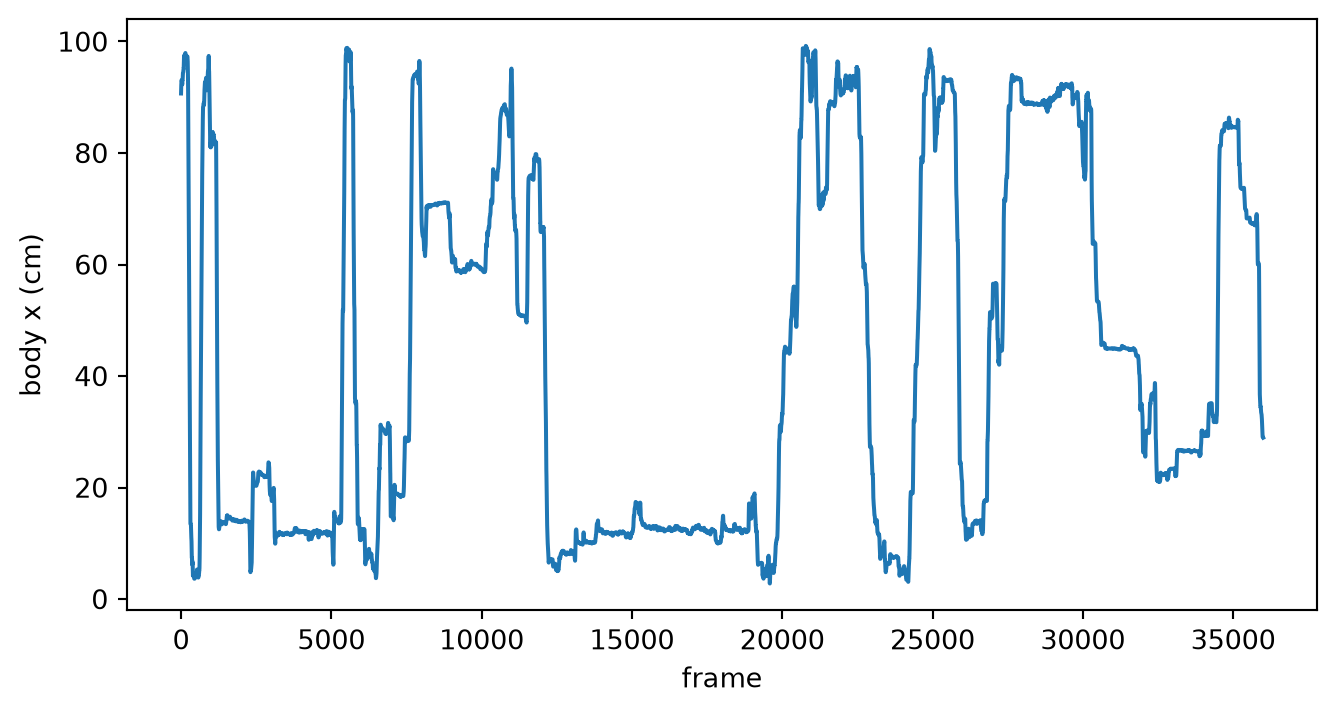

In [19]:
import matplotlib.pyplot as plt

plt.plot(body_x)
plt.xlabel("frame")
plt.ylabel("body x (cm)")
plt.show()

## Math on the whole array at once {.smaller .scrollable}

In [20]:
fps = 50
time_s = np.arange(len(body_x)) / fps      # frame number -> seconds
time_s[:5], time_s[-1]

(array([0.  , 0.02, 0.04, 0.06, 0.08]), np.float64(720.0))

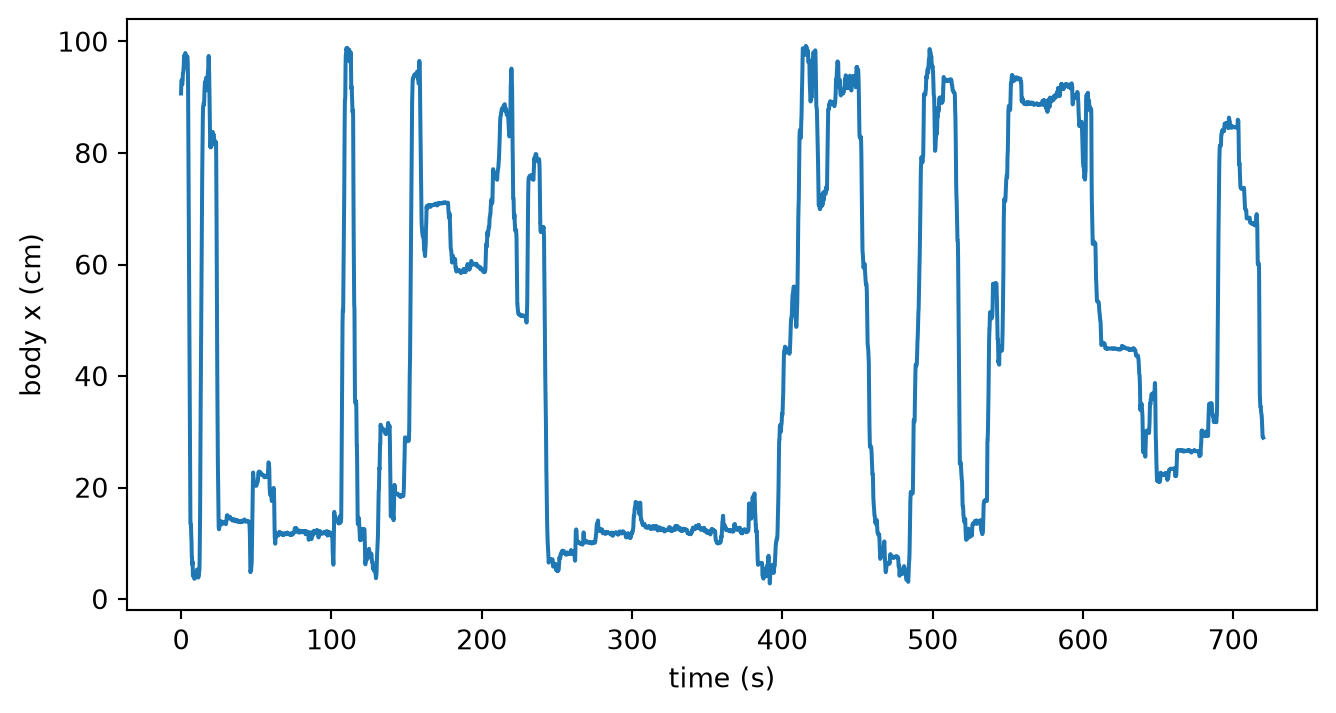

In [21]:
plt.plot(time_s, body_x)
plt.xlabel("time (s)")
plt.ylabel("body x (cm)")
plt.show()

- This needs no loop. `np.arange` makes the numbers 0, 1, 2, up to 36 000. Then `/ fps` divides every value.

## From position to speed

In [22]:
dx = np.diff(body_x)      # x[1]-x[0], x[2]-x[1], ...
dy = np.diff(body_y)
dx.shape

(36000,)

In [23]:
speed = np.sqrt(dx**2 + dy**2) * fps    # cm per frame -> cm per second
np.median(speed), speed.max()

(np.float64(1.205458901348797), np.float64(120.75136636967443))

- The result has one value fewer: 36 000 differences from 36 001 positions.

## Boolean arrays: one question, every value

In [24]:
moving = speed > 5        # cm/s
moving[:10]

array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True])

In [25]:
moving.sum(), moving.mean()      # True counts as 1

(np.int64(9417), np.float64(0.26158333333333333))

- The rat moves faster than 5 cm/s about one quarter of the time.

## Boolean arrays select values

In [26]:
speed[moving].mean(), speed[~moving].mean()

(np.float64(17.67765193002273), np.float64(1.0894099304193838))

In [27]:
np.where(moving)[0][:10]       # frame numbers where it is True

array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10])

## The path

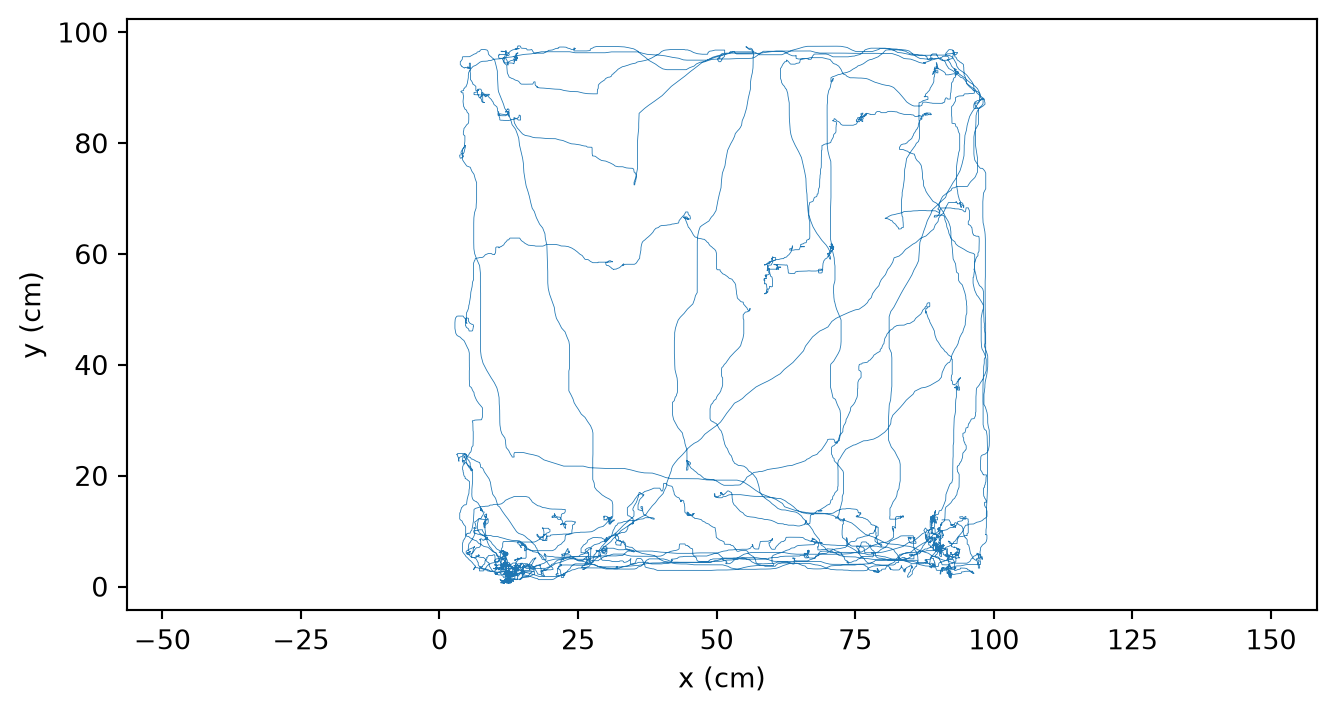

In [28]:
plt.plot(body_x, body_y, linewidth=0.3)
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")
plt.axis("equal")
plt.show()

# Part 3. Two and three dimensions: a frame is an array

## Read one frame of the video

In [29]:
import imageio.v3 as iio

frame = iio.imread("data/video.mp4", index=9000, plugin="pyav")
frame.shape, frame.dtype

((388, 410, 3), dtype('uint8'))

- The frame has 388 rows, 410 columns, and 3 colors: red, green, and blue. Values go from 0 to 255.

## Show it

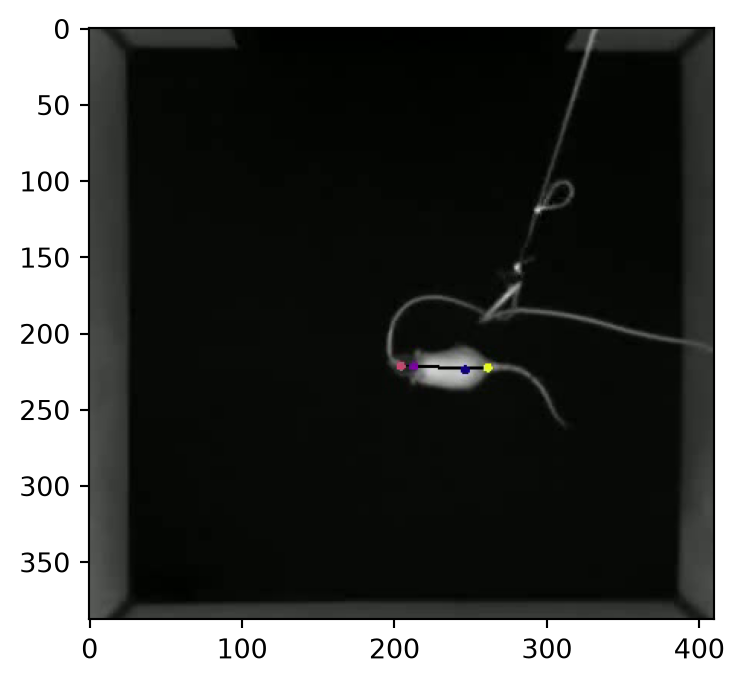

In [30]:
plt.imshow(frame)
plt.show()

## An image is numbers

In [31]:
frame[200:205, 220:225, 0]      # a 5x5 patch of the red channel

array([[8, 8, 8, 8, 8],
       [8, 8, 8, 8, 8],
       [8, 8, 8, 8, 8],
       [8, 8, 8, 8, 8],
       [8, 8, 8, 8, 8]], dtype=uint8)

- Index order is `[row, column, channel]`. Row 0 is at the top.

## One channel at a time

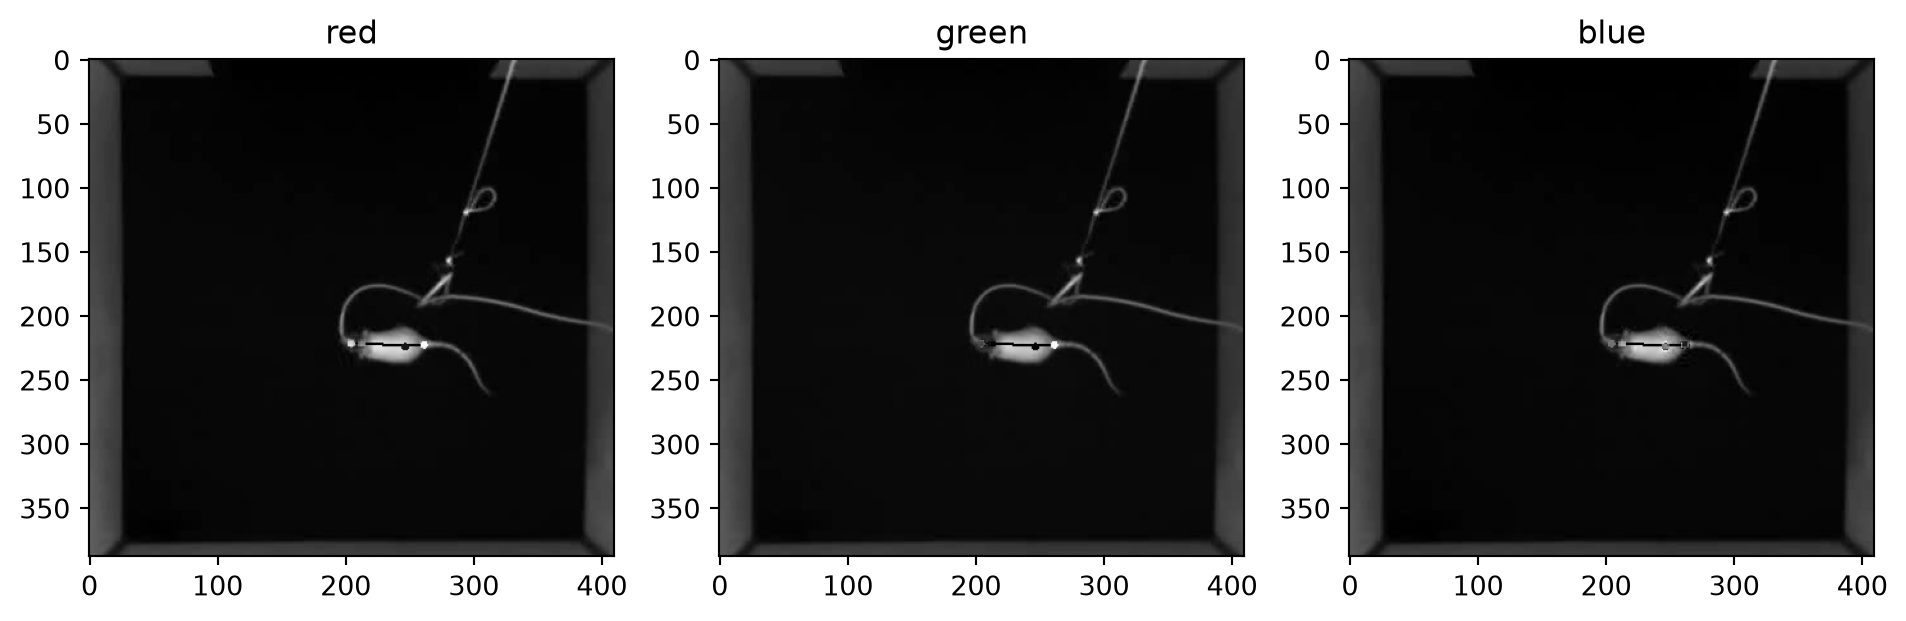

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, name in enumerate(["red", "green", "blue"]):
    axes[i].imshow(frame[:, :, i], cmap="gray")
    axes[i].set_title(name)
plt.show()

## Reduce along an axis

In [33]:
gray = frame.mean(axis=2)       # average of the 3 colors
gray.shape

(388, 410)

- `axis=2` means: collapse the third dimension. The result has one dimension fewer.
- `axis=0` collapses rows, `axis=1` collapses columns. The same rule applies to `sum`, `max`, and `median`.

## Crop the arena

In [34]:
import json

corners = json.load(open("data/video.json"))["PixelCoordinates"]
corners

{'LongName': 'Important pixel coordinates in the video recording.',
 'top_left': [23, 14],
 'top_right': [388, 16],
 'bottom_left': [24, 377],
 'bottom_right': [384, 374]}

- A JSON file opens as a dict.

## Slice rows and columns

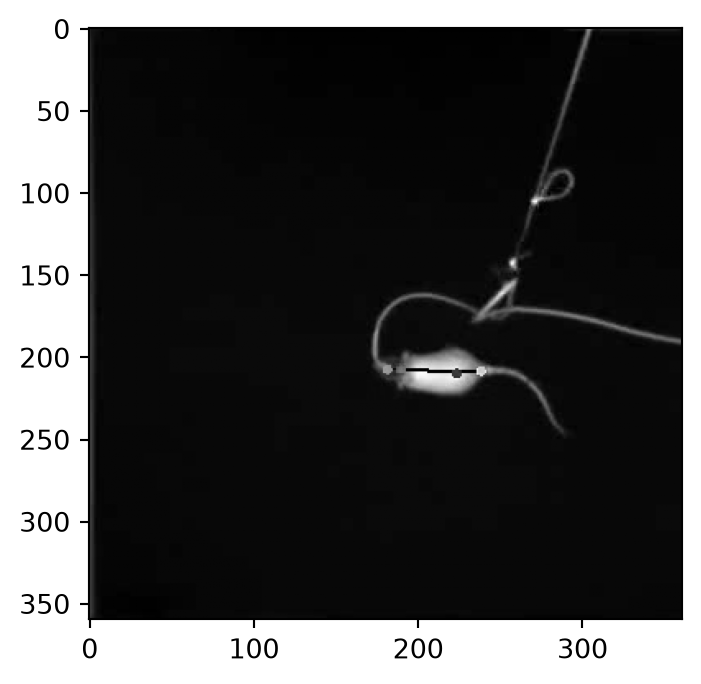

In [35]:
x0, y0 = corners["top_left"]
x1, y1 = corners["bottom_right"]
arena = gray[y0:y1, x0:x1]
plt.imshow(arena, cmap="gray")
plt.show()

- A 2-D slice is `[rows, columns]`.

## The brightest pixel

In [36]:
arena.max(), arena.argmax()

(np.float64(212.33333333333334), np.int64(75651))

In [37]:
np.unravel_index(arena.argmax(), arena.shape)

(np.int64(209), np.int64(202))

- `argmax` counts through the array as if it were flat. `unravel_index` returns the row and the column.

## Threshold: the rat is bright

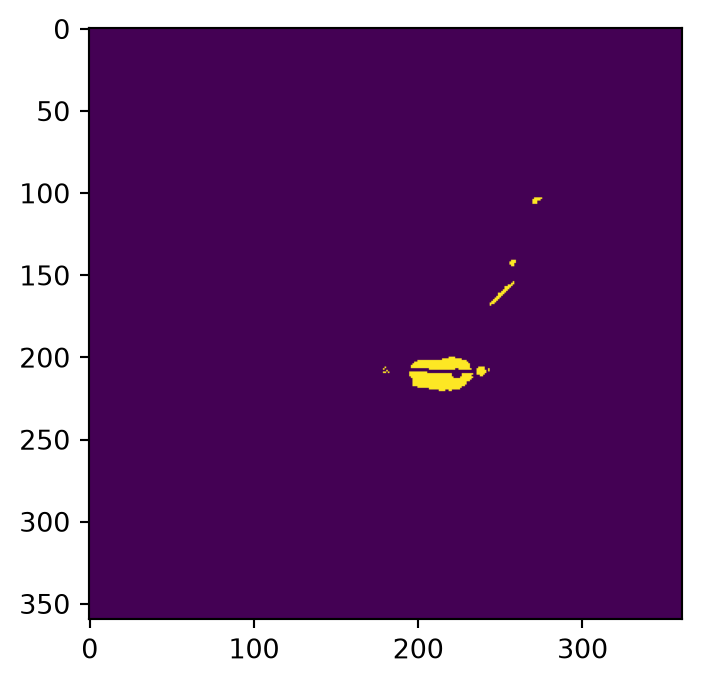

In [38]:
bright = arena > np.percentile(arena, 99.5)
plt.imshow(bright)
plt.show()

## From a mask to a position

In [39]:
cm_per_px = 0.2766                     # from channels.tsv
rows, cols = np.where(bright)
cols.mean() * cm_per_px, rows.mean() * cm_per_px, body_x[9000], body_y[9000]

(np.float64(60.630121483771255),
 np.float64(56.17160309119011),
 np.float64(61.75347951221808),
 np.float64(58.05563030057305))

- The mean of the pixel coordinates is the center of the bright area.
- This point is about 2 cm from the DeepLabCut point. Three lines of code give this result.

## It fails on other frames

In [40]:
frame2 = iio.imread("data/video.mp4", index=3000, plugin="pyav")
arena2 = frame2.mean(axis=2)[y0:y1, x0:x1]
bright2 = arena2 > np.percentile(arena2, 99.5)
rows, cols = np.where(bright2)
cols.mean() * cm_per_px, rows.mean() * cm_per_px, body_x[3000], body_y[3000]

(np.float64(34.687435548686246),
 np.float64(16.486129520865536),
 np.float64(18.78824608499722),
 np.float64(8.341931066810641))

- This position is 18 cm off. The cable on the rat's head is bright too.

## Fix: blur first

In [41]:
from scipy import ndimage

smooth2 = ndimage.uniform_filter(arena2, size=21)
bright2 = smooth2 > np.percentile(smooth2, 99.5)
rows, cols = np.where(bright2)
cols.mean() * cm_per_px, rows.mean() * cm_per_px

(np.float64(16.749193846153847), np.float64(7.5320307692307695))

- A blur is the mean over a 21×21 window. The thin cable disappears. The fat rat stays.
- You tracked a rat by hand. DeepLabCut does the same job with a neural network.

## Three dimensions: a stack of frames {.smaller}

In [42]:
indices = range(0, 36000, 3600)
stack = np.stack([iio.imread("data/video.mp4", index=i, plugin="pyav").mean(axis=2)[y0:y1, x0:x1]
                  for i in indices])
stack.shape

(10, 360, 361)

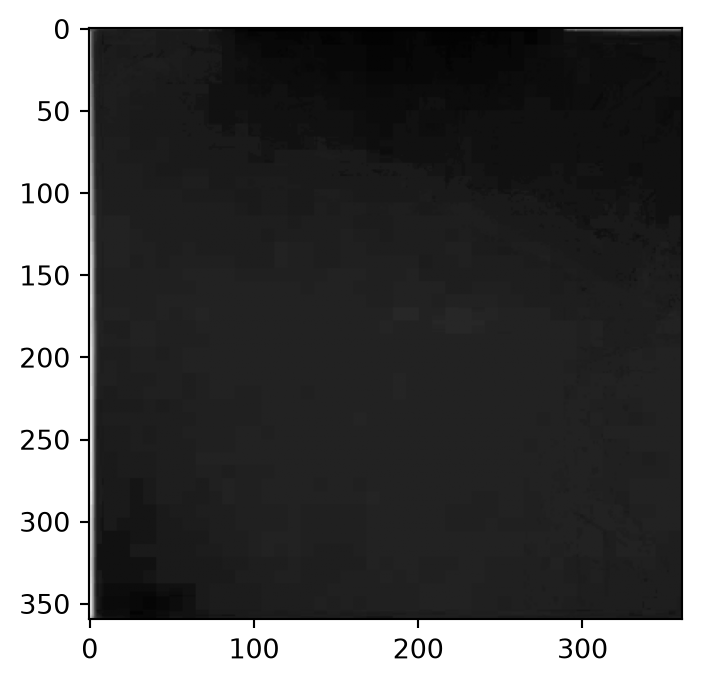

In [43]:
background = np.median(stack, axis=0)
plt.imshow(background, cmap="gray")
plt.show()

- This takes the median over the frame axis. The rat moves, so it disappears. The arena stays.

# Part 4. matplotlib, properly

## Figure, axes, plot

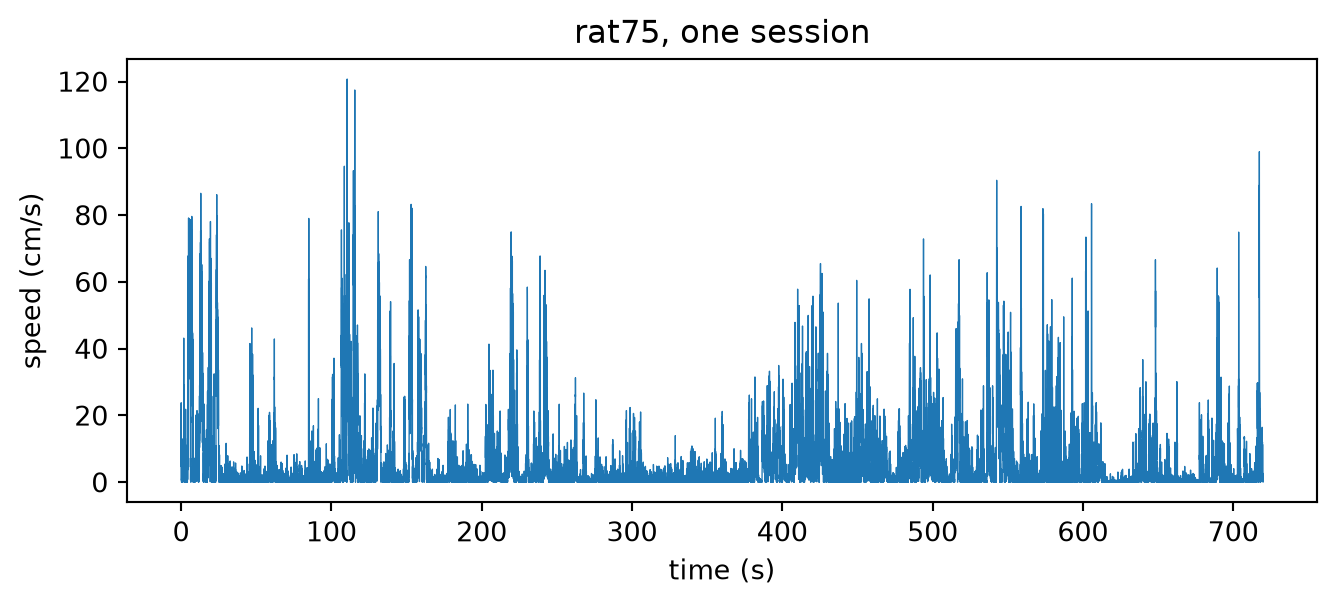

In [44]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time_s[:-1], speed, linewidth=0.5)
ax.set_xlabel("time (s)")
ax.set_ylabel("speed (cm/s)")
ax.set_title("rat75, one session")
plt.show()

- `fig` is the page. `ax` is one plot on the page. Most functions belong to `ax`.

## Several plots on one figure

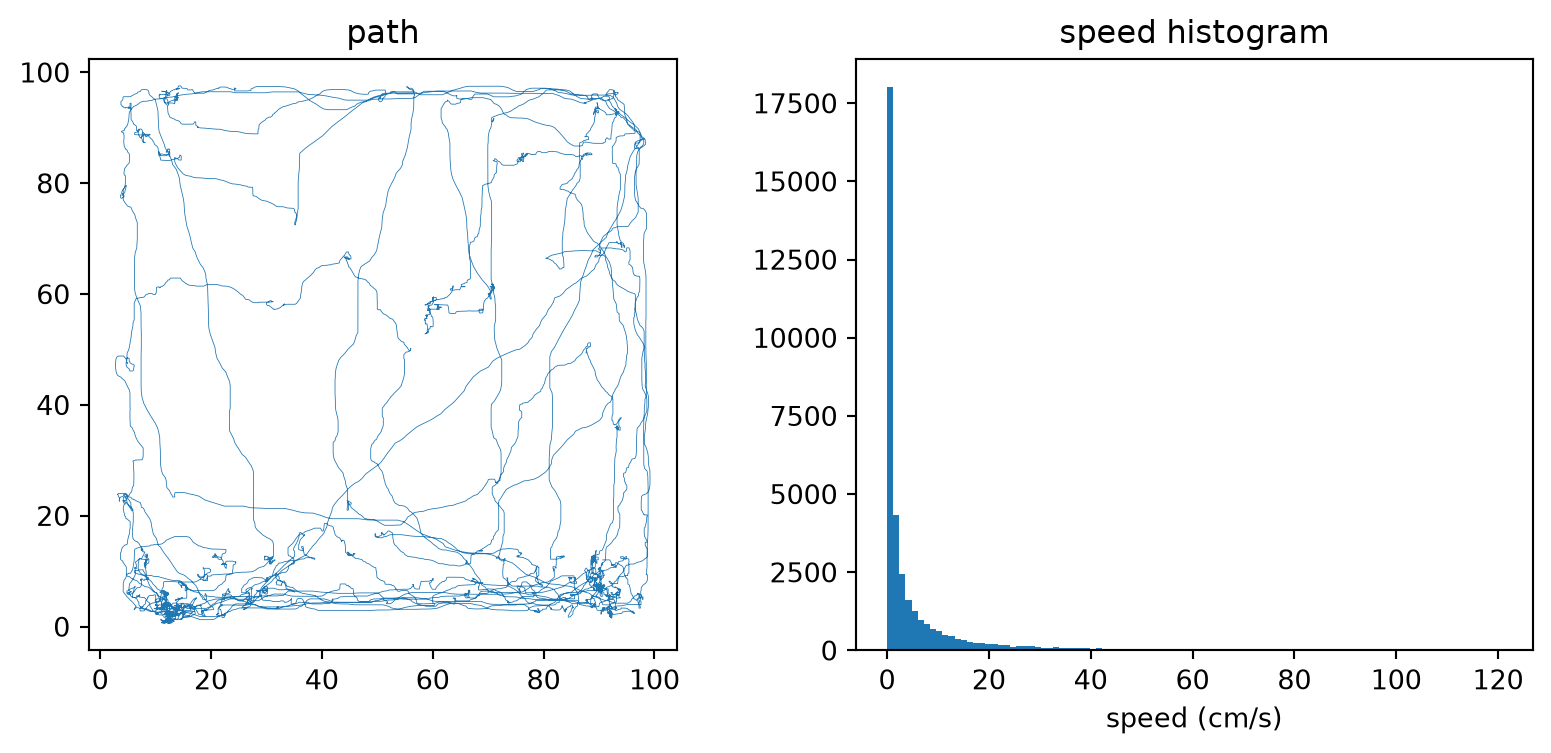

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(body_x, body_y, linewidth=0.3)
ax1.set_aspect("equal")
ax1.set_title("path")
ax2.hist(speed, bins=100)
ax2.set_xlabel("speed (cm/s)")
ax2.set_title("speed histogram")
plt.show()

## A histogram with a log scale

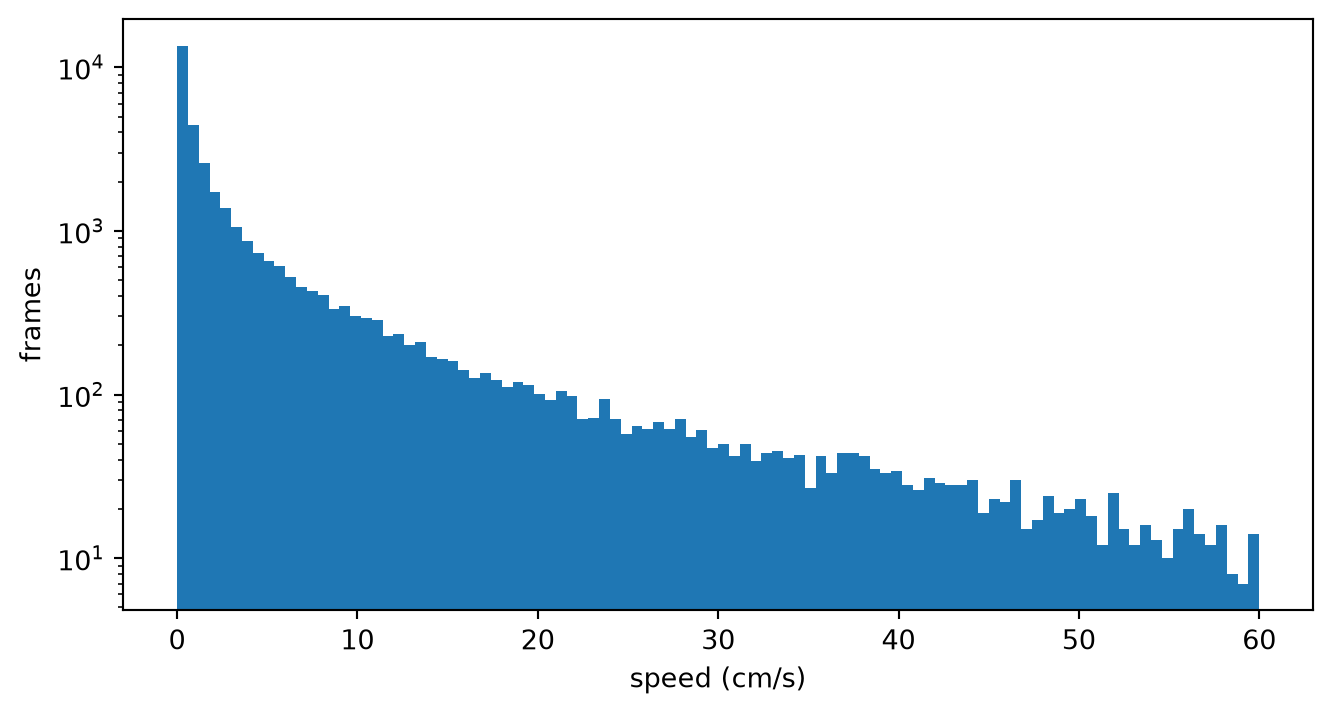

In [46]:
fig, ax = plt.subplots()
ax.hist(speed, bins=100, range=(0, 60))
ax.set_yscale("log")
ax.set_xlabel("speed (cm/s)")
ax.set_ylabel("frames")
plt.show()

## An image with a color bar

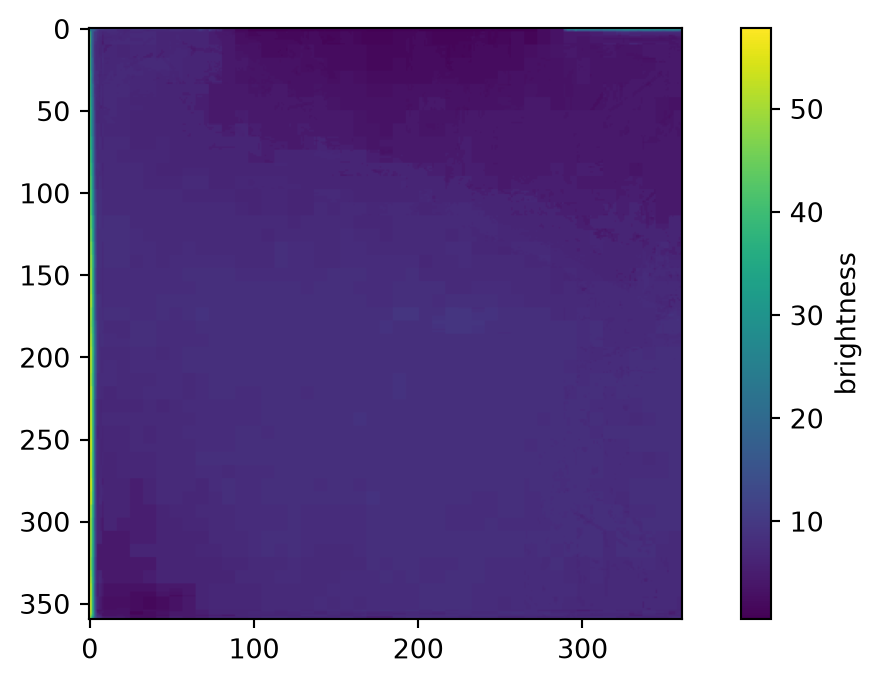

In [47]:
fig, ax = plt.subplots()
im = ax.imshow(background, cmap="viridis")
fig.colorbar(im, ax=ax, label="brightness")
plt.show()

## A heat map from two columns {.smaller}

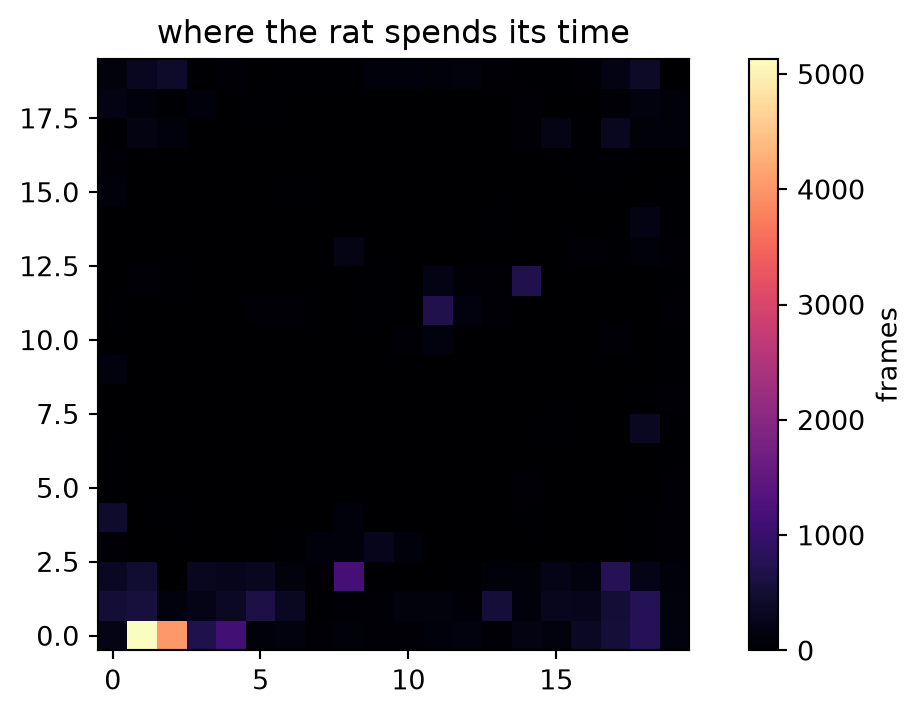

In [48]:
counts, x_edges, y_edges = np.histogram2d(body_x, body_y, bins=20)
fig, ax = plt.subplots()
im = ax.imshow(counts.T, origin="lower", cmap="magma")
fig.colorbar(im, ax=ax, label="frames")
ax.set_title("where the rat spends its time")
plt.show()

- `.T` transposes the array. `histogram2d` returns `[x, y]`. `imshow` wants `[row, column]`.

## Save it

In [49]:
fig.savefig("occupancy.png", dpi=150)

- Always label the axes. Always write the units.

# Part 5. How the practical works

## Fill the blank, run the check

In [50]:
# YOUR CODE HERE
n_frames = ...

In [51]:
n_frames = len(body_x)
assert n_frames == 36001, "count the frames, not the seconds"

- `assert` stops with an error when the condition is False. When it is True, it prints nothing.
- Replace `...` with your code. Run the next cell. No error means your answer is correct.
- Work in pairs. Ask early.